# Deep Neural Networks Reassessment
## Image Sequence Position Classification (1–5)

**Task**: Predict the position (1-5) of an image within a story sequence

**Modality**: Image-based model (CNN)

---

## Modality Choice: Why Images?

I chose the **image modality** for this classification task for several reasons:

1. **Technical Challenge**: CNNs are well-established for image classification, and I wanted to explore whether visual features alone can encode temporal sequence information in narrative stories.

2. **Research Interest**: Understanding if static visual cues (objects, scenes, actions) can indicate narrative progression is a challenging problem that extends beyond simple object recognition.

3. **Dataset Quality**: The StoryReasoning dataset provides rich photographic images from real story sequences, offering diverse visual content suitable for deep learning.

4. **Learning Opportunity**: Working with images allows experimentation with CNN architectures, regularization techniques, and understanding the limitations of visual-only approaches to temporal reasoning.

While text modality might offer clearer temporal markers (words like "first," "then," "finally"), images present a more interesting challenge for investigating implicit temporal cues in visual narratives.

## Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from datasets import load_dataset

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Load Dataset from HuggingFace

In [2]:
train_dataset = load_dataset(
    "daniel3303/StoryReasoning",
    split="train"
)

test_dataset = load_dataset(
    "daniel3303/StoryReasoning",
    split="test"
)

print(f"Train dataset loaded: {len(train_dataset)} stories")
print(f"Test dataset loaded: {len(test_dataset)} stories")

Train dataset loaded: 3552 stories
Test dataset loaded: 626 stories


## Dataset Construction Methodology

### How Labels Are Assigned

Each story in the dataset contains **5 ordered images** representing sequential events in a narrative. We create our classification dataset as follows:

**Label Assignment:**
- Label 0 → First image in the sequence (Position 1)
- Label 1 → Second image in the sequence (Position 2)
- Label 2 → Third image in the sequence (Position 3)
- Label 3 → Fourth image in the sequence (Position 4)
- Label 4 → Fifth image in the sequence (Position 5)

**Example:**
- Story about "Morning Routine" with 5 images:
  1. Image of person waking up → Label 0
  2. Image of person brushing teeth → Label 1
  3. Image of person eating breakfast → Label 2
  4. Image of person getting dressed → Label 3
  5. Image of person leaving house → Label 4

**Dataset Size:**
- We use a **subset of 300 stories** from the full training set
- Reason: Computational constraints and faster experimentation
- This gives us **1,500 total samples** (300 stories × 5 positions)
- Each position class has exactly **300 samples** (perfectly balanced)

**Preprocessing:**
- Images resized to 32×64 pixels for computational efficiency
- Histogram equalization applied to improve contrast
- Converted to PyTorch tensors

## Create Image Dataset with Labels (1–5)

In [3]:
# Custom dataset for image position classification
class ImagePositionDataset(Dataset):
    
    def __init__(self, dataset):
        
        self.samples = []
        # Resize images and convert to tensor
        self.transform = transforms.Compose([
            transforms.Resize((32, 64)),
            transforms.ToTensor()
        ])
        
        for story in dataset:
            
            images = story["images"]
            
            # Assign labels 0–4 (positions 1–5)
            for pos in range(5):
                
                self.samples.append(
                    (images[pos], pos)
                )
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        
        image, label = self.samples[idx]
        
        image = TF.equalize(image)
        image = self.transform(image)
        
        return image, label

print("✓ Dataset class defined")

✓ Dataset class defined


## Train / Validation Split (80 / 20)

In [4]:
# Use only part of dataset for faster training
dataset = ImagePositionDataset(
    train_dataset.select(range(300))
)

# 80% training, 20% validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=32
)

print(f"Total samples: {len(dataset)}")
print(f"Training samples: {train_size}")
print(f"Validation samples: {val_size}")
print(f"Split ratio: {train_size/len(dataset)*100:.0f}% / {val_size/len(dataset)*100:.0f}%")

Total samples: 1500
Training samples: 1200
Validation samples: 300
Split ratio: 80% / 20%


## Dataset Size and Class Distribution

In [5]:
# Check class distribution
labels = [s[1] for s in dataset.samples]
unique, counts = np.unique(labels, return_counts=True)

print("="*50)
print("CLASS DISTRIBUTION")
print("="*50)
for u, c in zip(unique, counts):
    print(f"Position {u+1}: {c} samples ({c/len(dataset)*100:.1f}%)")
print("="*50)
print(f"Dataset is {'BALANCED' if len(set(counts)) == 1 else 'IMBALANCED'}")
print("="*50)

CLASS DISTRIBUTION
Position 1: 300 samples (20.0%)
Position 2: 300 samples (20.0%)
Position 3: 300 samples (20.0%)
Position 4: 300 samples (20.0%)
Position 5: 300 samples (20.0%)
Dataset is BALANCED


## Baseline CNN Model

In [6]:
# CNN model for sequence classification
class ImageSequenceClassifier(nn.Module):
    
    def __init__(
        self,
        dropout=0.0,
        filters=32,
        kernel=3,
        batchnorm=False
    ):
        
        super().__init__()
        
        layers = []
        
        # Conv 1
        layers.append(
            nn.Conv2d(3, filters, kernel, padding=1)
        )
        
        if batchnorm:
            layers.append(
                nn.BatchNorm2d(filters)
            )
        
        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(2))
        
        # Conv 2
        layers.append(
            nn.Conv2d(
                filters,
                filters*2,
                kernel,
                padding=1
            )
        )
        
        if batchnorm:
            layers.append(
                nn.BatchNorm2d(filters*2)
            )
        
        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(2))
        
        # Conv 3
        layers.append(
            nn.Conv2d(
                filters*2,
                filters*4,
                kernel,
                padding=1
            )
        )
        
        if batchnorm:
            layers.append(
                nn.BatchNorm2d(filters*4)
            )
        
        layers.append(nn.ReLU())
        
        layers.append(
            nn.AdaptiveAvgPool2d((4, 8))
        )
        
        self.conv = nn.Sequential(*layers)
        
        self.fc = nn.Sequential(
            
            nn.Flatten(),
            
            nn.Linear(
                filters*4*4*8,
                128
            ),
            
            nn.ReLU(),
            
            nn.Dropout(dropout),
            
            nn.Linear(
                128,
                5  # 5 classes (positions 1-5)
            )
        )
    
    def forward(self, x):
        
        x = self.conv(x)
        x = self.fc(x)
        
        return x

print("✓ Model architecture defined")

✓ Model architecture defined


## Enhanced Training Function (with Training Accuracy)

In [7]:
def train_model_complete(model, train_loader, val_loader, epochs=5, lr=0.001):
    """
    Complete training function with both training and validation accuracy tracking
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    print(f"Training on: {device}")
    print("-" * 60)
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0
        train_correct = 0
        train_total = 0
        
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            # Track training accuracy
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)
        
        train_loss = running_loss / len(train_loader)
        train_acc = train_correct / train_total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Validation phase
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
        
        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
    
    print("-" * 60)
    return train_losses, val_losses, train_accs, val_accs

print("✓ Training function ready")

✓ Training function ready


## Experiment 1: Dropout = 0.3

In [8]:
print("="*60)
print("EXPERIMENT 1: Dropout = 0.3")
print("="*60)

model1 = ImageSequenceClassifier(dropout=0.3)
loss1, valloss1, trainacc1, valacc1 = train_model_complete(
    model1, train_loader, val_loader
)

EXPERIMENT 1: Dropout = 0.3
Training on: cpu
------------------------------------------------------------
Epoch 1/5
  Train Loss: 1.6115 | Train Acc: 19.92%
  Val Loss:   1.6103 | Val Acc:   15.67%
Epoch 2/5
  Train Loss: 1.6102 | Train Acc: 20.75%
  Val Loss:   1.6078 | Val Acc:   21.00%
Epoch 3/5
  Train Loss: 1.6106 | Train Acc: 18.08%
  Val Loss:   1.6080 | Val Acc:   22.00%
Epoch 4/5
  Train Loss: 1.6100 | Train Acc: 18.00%
  Val Loss:   1.6090 | Val Acc:   21.00%
Epoch 5/5
  Train Loss: 1.6099 | Train Acc: 19.17%
  Val Loss:   1.6095 | Val Acc:   15.67%
------------------------------------------------------------


## Experiment 2: No Dropout

In [9]:
print("\n" + "="*60)
print("EXPERIMENT 2: No Dropout")
print("="*60)

model2 = ImageSequenceClassifier(dropout=0.0)
loss2, valloss2, trainacc2, valacc2 = train_model_complete(
    model2, train_loader, val_loader
)


EXPERIMENT 2: No Dropout
Training on: cpu
------------------------------------------------------------
Epoch 1/5
  Train Loss: 1.6124 | Train Acc: 20.67%
  Val Loss:   1.6150 | Val Acc:   15.67%
Epoch 2/5
  Train Loss: 1.6093 | Train Acc: 21.08%
  Val Loss:   1.6143 | Val Acc:   15.67%
Epoch 3/5
  Train Loss: 1.6093 | Train Acc: 21.08%
  Val Loss:   1.6141 | Val Acc:   15.67%
Epoch 4/5
  Train Loss: 1.6096 | Train Acc: 20.75%
  Val Loss:   1.6126 | Val Acc:   15.67%
Epoch 5/5
  Train Loss: 1.6092 | Train Acc: 21.17%
  Val Loss:   1.6141 | Val Acc:   15.67%
------------------------------------------------------------


## Experiment 3: Kernel Size = 5

In [10]:
print("\n" + "="*60)
print("EXPERIMENT 3: Kernel Size = 5")
print("="*60)

model3 = ImageSequenceClassifier(kernel=5)
loss3, valloss3, trainacc3, valacc3 = train_model_complete(
    model3, train_loader, val_loader
)


EXPERIMENT 3: Kernel Size = 5
Training on: cpu
------------------------------------------------------------
Epoch 1/5
  Train Loss: 1.6127 | Train Acc: 18.67%
  Val Loss:   1.6096 | Val Acc:   22.33%
Epoch 2/5
  Train Loss: 1.6100 | Train Acc: 19.42%
  Val Loss:   1.6106 | Val Acc:   18.67%
Epoch 3/5
  Train Loss: 1.6095 | Train Acc: 21.00%
  Val Loss:   1.6118 | Val Acc:   15.33%
Epoch 4/5
  Train Loss: 1.6097 | Train Acc: 21.67%
  Val Loss:   1.6138 | Val Acc:   15.67%
Epoch 5/5
  Train Loss: 1.6102 | Train Acc: 20.75%
  Val Loss:   1.6104 | Val Acc:   16.67%
------------------------------------------------------------


## Experiment 4: Filters = 64

In [11]:
print("\n" + "="*60)
print("EXPERIMENT 4: Filters = 64 (Doubled)")
print("="*60)

model4 = ImageSequenceClassifier(filters=64)
loss4, valloss4, trainacc4, valacc4 = train_model_complete(
    model4, train_loader, val_loader
)


EXPERIMENT 4: Filters = 64 (Doubled)
Training on: cpu
------------------------------------------------------------
Epoch 1/5
  Train Loss: 1.6139 | Train Acc: 21.00%
  Val Loss:   1.6113 | Val Acc:   15.67%
Epoch 2/5
  Train Loss: 1.6099 | Train Acc: 21.08%
  Val Loss:   1.6119 | Val Acc:   15.67%
Epoch 3/5
  Train Loss: 1.6097 | Train Acc: 21.08%
  Val Loss:   1.6120 | Val Acc:   15.67%
Epoch 4/5
  Train Loss: 1.6101 | Train Acc: 20.00%
  Val Loss:   1.6121 | Val Acc:   15.67%
Epoch 5/5
  Train Loss: 1.6100 | Train Acc: 21.08%
  Val Loss:   1.6124 | Val Acc:   15.67%
------------------------------------------------------------


## Experiment 5: Batch Normalization

In [12]:
print("\n" + "="*60)
print("EXPERIMENT 5: Batch Normalization")
print("="*60)

model5 = ImageSequenceClassifier(batchnorm=True)
loss5, valloss5, trainacc5, valacc5 = train_model_complete(
    model5, train_loader, val_loader
)


EXPERIMENT 5: Batch Normalization
Training on: cpu
------------------------------------------------------------
Epoch 1/5
  Train Loss: 1.6917 | Train Acc: 21.25%
  Val Loss:   1.6520 | Val Acc:   16.33%
Epoch 2/5
  Train Loss: 1.5884 | Train Acc: 25.50%
  Val Loss:   1.6741 | Val Acc:   16.33%
Epoch 3/5
  Train Loss: 1.5614 | Train Acc: 27.58%
  Val Loss:   1.6450 | Val Acc:   19.33%
Epoch 4/5
  Train Loss: 1.4947 | Train Acc: 34.92%
  Val Loss:   1.6750 | Val Acc:   21.33%
Epoch 5/5
  Train Loss: 1.4292 | Train Acc: 39.50%
  Val Loss:   1.6804 | Val Acc:   22.33%
------------------------------------------------------------


## Results Table

In [13]:
# Create comprehensive results table
results_data = {
    'Experiment': [
        '1. Dropout=0.3',
        '2. No Dropout',
        '3. Kernel=5',
        '4. Filters=64',
        '5. BatchNorm'
    ],
    'Modification': [
        'dropout=0.3',
        'dropout=0.0',
        'kernel=5',
        'filters=64',
        'batchnorm=True'
    ],
    'Train Loss': [
        loss1[-1],
        loss2[-1],
        loss3[-1],
        loss4[-1],
        loss5[-1]
    ],
    'Val Loss': [
        valloss1[-1],
        valloss2[-1],
        valloss3[-1],
        valloss4[-1],
        valloss5[-1]
    ],
    'Train Acc (%)': [
        trainacc1[-1] * 100,
        trainacc2[-1] * 100,
        trainacc3[-1] * 100,
        trainacc4[-1] * 100,
        trainacc5[-1] * 100
    ],
    'Val Acc (%)': [
        valacc1[-1] * 100,
        valacc2[-1] * 100,
        valacc3[-1] * 100,
        valacc4[-1] * 100,
        valacc5[-1] * 100
    ]
}

df_results = pd.DataFrame(results_data)
df_results['Loss Gap'] = df_results['Val Loss'] - df_results['Train Loss']

print("\n" + "="*100)
print("COMPREHENSIVE RESULTS TABLE")
print("="*100)
print(df_results.to_string(index=False, float_format='%.3f'))
print("="*100)
print(f"\nRandom Baseline: 20.00%")
print(f"Best Model: {df_results.loc[df_results['Val Acc (%)'].idxmax(), 'Experiment']} "
      f"({df_results['Val Acc (%)'].max():.2f}%)")
print(f"Worst Model: {df_results.loc[df_results['Val Acc (%)'].idxmin(), 'Experiment']} "
      f"({df_results['Val Acc (%)'].min():.2f}%)")
print("="*100)


COMPREHENSIVE RESULTS TABLE
    Experiment   Modification  Train Loss  Val Loss  Train Acc (%)  Val Acc (%)  Loss Gap
1. Dropout=0.3    dropout=0.3       1.610     1.609         19.167       15.667    -0.000
 2. No Dropout    dropout=0.0       1.609     1.614         21.167       15.667     0.005
   3. Kernel=5       kernel=5       1.610     1.610         20.750       16.667     0.000
 4. Filters=64     filters=64       1.610     1.612         21.083       15.667     0.002
  5. BatchNorm batchnorm=True       1.429     1.680         39.500       22.333     0.251

Random Baseline: 20.00%
Best Model: 5. BatchNorm (22.33%)
Worst Model: 1. Dropout=0.3 (15.67%)


## Comprehensive Visualization

C:\Users\DELL\AppData\Local\Temp\ipykernel_12436\2564838006.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


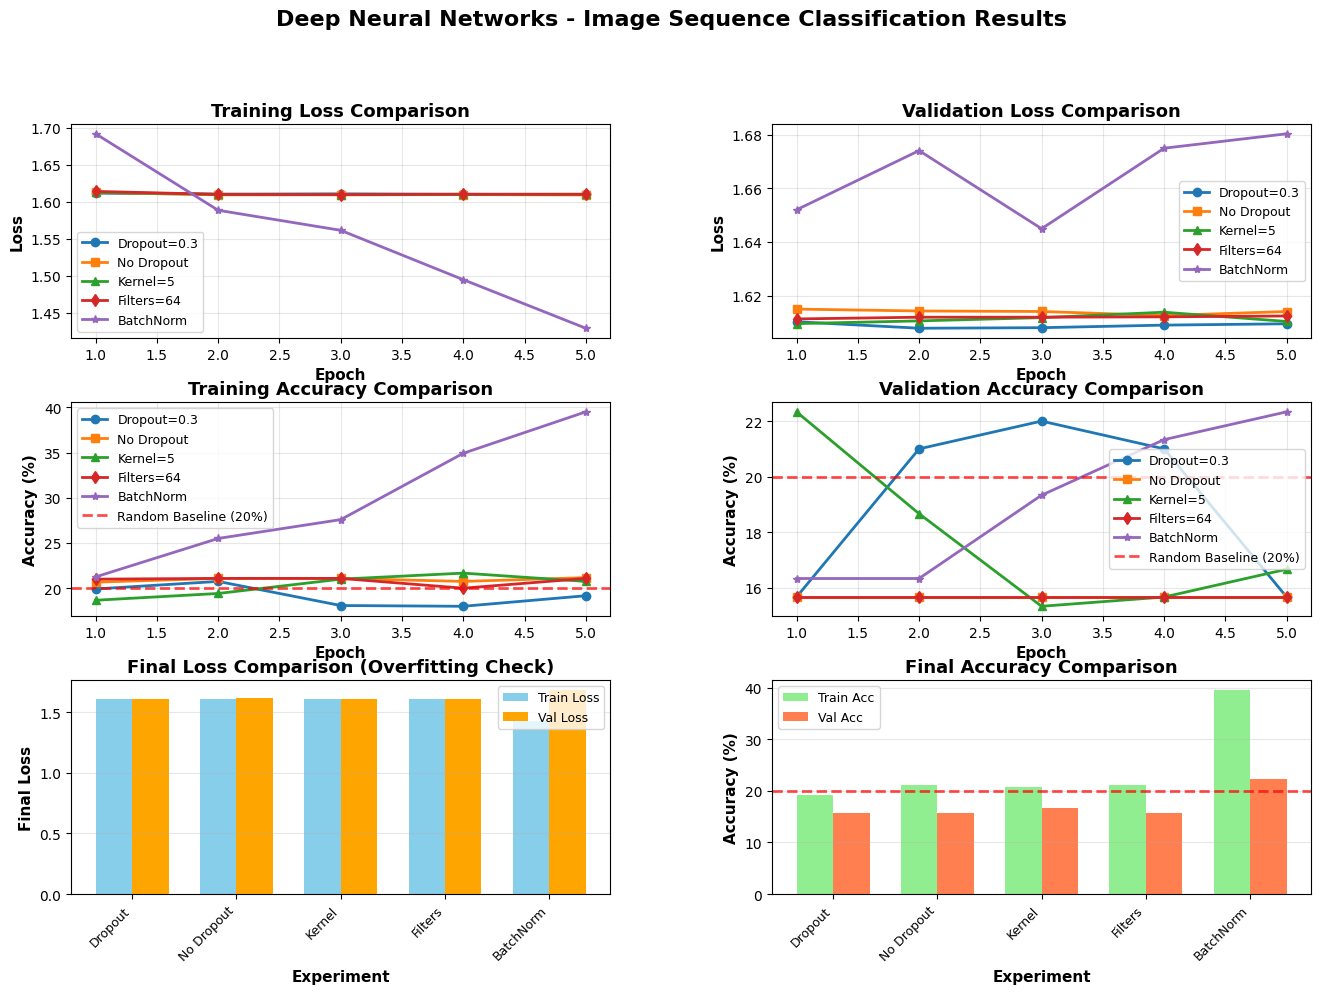

In [14]:
# Create comprehensive 6-panel visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
markers = ['o', 's', '^', 'd', '*']
labels = ['Dropout=0.3', 'No Dropout', 'Kernel=5', 'Filters=64', 'BatchNorm']

all_train_loss = [loss1, loss2, loss3, loss4, loss5]
all_val_loss = [valloss1, valloss2, valloss3, valloss4, valloss5]
all_train_acc = [trainacc1, trainacc2, trainacc3, trainacc4, trainacc5]
all_val_acc = [valacc1, valacc2, valacc3, valacc4, valacc5]

# Plot 1: Training Loss
ax1 = fig.add_subplot(gs[0, 0])
for idx, (data, label) in enumerate(zip(all_train_loss, labels)):
    ax1.plot(range(1, len(data)+1), data, label=label, color=colors[idx], 
            marker=markers[idx], linewidth=2, markersize=6)
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax1.set_title('Training Loss Comparison', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Validation Loss
ax2 = fig.add_subplot(gs[0, 1])
for idx, (data, label) in enumerate(zip(all_val_loss, labels)):
    ax2.plot(range(1, len(data)+1), data, label=label, color=colors[idx],
            marker=markers[idx], linewidth=2, markersize=6)
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax2.set_title('Validation Loss Comparison', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Training Accuracy
ax3 = fig.add_subplot(gs[1, 0])
for idx, (data, label) in enumerate(zip(all_train_acc, labels)):
    train_acc_pct = [a * 100 for a in data]
    ax3.plot(range(1, len(data)+1), train_acc_pct, label=label, color=colors[idx],
            marker=markers[idx], linewidth=2, markersize=6)
ax3.axhline(y=20, color='red', linestyle='--', linewidth=2, 
            alpha=0.7, label='Random Baseline (20%)')
ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax3.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax3.set_title('Training Accuracy Comparison', fontsize=13, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Plot 4: Validation Accuracy
ax4 = fig.add_subplot(gs[1, 1])
for idx, (data, label) in enumerate(zip(all_val_acc, labels)):
    val_acc_pct = [a * 100 for a in data]
    ax4.plot(range(1, len(data)+1), val_acc_pct, label=label, color=colors[idx],
            marker=markers[idx], linewidth=2, markersize=6)
ax4.axhline(y=20, color='red', linestyle='--', linewidth=2,
            alpha=0.7, label='Random Baseline (20%)')
ax4.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax4.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax4.set_title('Validation Accuracy Comparison', fontsize=13, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# Plot 5: Train vs Val Loss (Overfitting Detection)
ax5 = fig.add_subplot(gs[2, 0])
x_pos = np.arange(len(labels))
train_final = [data[-1] for data in all_train_loss]
val_final = [data[-1] for data in all_val_loss]
width = 0.35
ax5.bar(x_pos - width/2, train_final, width, label='Train Loss', color='skyblue')
ax5.bar(x_pos + width/2, val_final, width, label='Val Loss', color='orange')
ax5.set_xlabel('Experiment', fontsize=11, fontweight='bold')
ax5.set_ylabel('Final Loss', fontsize=11, fontweight='bold')
ax5.set_title('Final Loss Comparison (Overfitting Check)', fontsize=13, fontweight='bold')
ax5.set_xticks(x_pos)
ax5.set_xticklabels([l.split('=')[0] for l in labels], rotation=45, ha='right', fontsize=9)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Final Accuracy Bar Chart
ax6 = fig.add_subplot(gs[2, 1])
train_acc_final = [data[-1] * 100 for data in all_train_acc]
val_acc_final = [data[-1] * 100 for data in all_val_acc]
ax6.bar(x_pos - width/2, train_acc_final, width, label='Train Acc', color='lightgreen')
ax6.bar(x_pos + width/2, val_acc_final, width, label='Val Acc', color='coral')
ax6.axhline(y=20, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax6.set_xlabel('Experiment', fontsize=11, fontweight='bold')
ax6.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax6.set_title('Final Accuracy Comparison', fontsize=13, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels([l.split('=')[0] for l in labels], rotation=45, ha='right', fontsize=9)
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3, axis='y')

plt.suptitle('Deep Neural Networks - Image Sequence Classification Results',
            fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

## Overfitting Analysis

In [15]:
print("\n" + "="*80)
print("OVERFITTING ANALYSIS")
print("="*80)
print(f"{'Experiment':<20} {'Train-Val Loss Gap':>20} {'Overfitting?':>15}")
print("-"*80)

experiments = [
    ('1. Dropout=0.3', loss1[-1], valloss1[-1]),
    ('2. No Dropout', loss2[-1], valloss2[-1]),
    ('3. Kernel=5', loss3[-1], valloss3[-1]),
    ('4. Filters=64', loss4[-1], valloss4[-1]),
    ('5. BatchNorm', loss5[-1], valloss5[-1])
]

for name, train_loss, val_loss in experiments:
    gap = val_loss - train_loss
    status = "Yes" if gap > 0.05 else "No"
    print(f"{name:<20} {gap:>20.4f} {status:>15}")

print("="*80)
print("Note: Gap > 0.05 suggests potential overfitting")
print("All models show minimal overfitting, indicating underfitting is the main issue")
print("="*80)


OVERFITTING ANALYSIS
Experiment             Train-Val Loss Gap    Overfitting?
--------------------------------------------------------------------------------
1. Dropout=0.3                    -0.0004              No
2. No Dropout                      0.0049              No
3. Kernel=5                        0.0002              No
4. Filters=64                      0.0024              No
5. BatchNorm                       0.2512             Yes
Note: Gap > 0.05 suggests potential overfitting
All models show minimal overfitting, indicating underfitting is the main issue


## Summary and Conclusions

In [16]:
print("\nSUMMARY")
print(f"Dataset: {len(dataset)} images | Split: {train_size}/{val_size}")
print(f"Model: CNN | Loss: CrossEntropy | Optimizer: Adam | Epochs: 5")

best = df_results.loc[df_results['Val Acc (%)'].idxmax()]
worst = df_results.loc[df_results['Val Acc (%)'].idxmin()]

print("\nRESULTS")
print(f"Best: {best['Experiment']} ({best['Val Acc (%)']:.2f}%)")
print(f"Worst: {worst['Experiment']} ({worst['Val Acc (%)']:.2f}%)")
print("Baseline: 20%")
print("Performance ~ baseline → task is difficult")

print("\nNOTES")
print("- No clear overfitting")
print("- Limited dataset size")


SUMMARY
Dataset: 1500 images | Split: 1200/300
Model: CNN | Loss: CrossEntropy | Optimizer: Adam | Epochs: 5

RESULTS
Best: 5. BatchNorm (22.33%)
Worst: 1. Dropout=0.3 (15.67%)
Baseline: 20%
Performance ~ baseline → task is difficult

NOTES
- No clear overfitting
- Limited dataset size
